## Iterative Training and Screening with Li-CO2 Models

This notebook trains TabPFN regressors for Li-CO2 overpotential
using datasets from iterations 0–6.

### Workflow

1. Independently split each dataset by compound into training and
   test sets, reserving 20% of compound groups for testing.
2. Train models and evaluate R², MAE, and RMSE, including five-fold
   grouped cross-validation within each training set.
3. Save prediction scatter plots and their underlying data.
4. Calculate individual and grouped permutation importance for
   iteration 6 using up to 256 test samples and three repeats.

Training requires CUDA and the specified local TabPFN checkpoint.
Screening and importance analysis use trained models stored in memory;
run the training section first. These two analyses can then run independently.

### CO2

In [1]:
# ============================================================
# 1. Import libraries
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tabpfn import TabPFNRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)

from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold
)

In [2]:
# ============================================================
# 2. Load data and group split
# ============================================================

DATA_FILES = {
    "Iteration_0": "data/compound_0_CO2.csv",
    "Iteration_1": "data/compound_1_CO2.csv",
    "Iteration_2": "data/compound_2_CO2.csv",
    "Iteration_3": "data/compound_3_CO2.csv",
    "Iteration_4": "data/compound_4_CO2.csv",
    "Iteration_5": "data/compound_5_CO2.csv",
    "Iteration_6": "data/compound_6_CO2.csv"
}

GROUP_COL = "compound"

RANDOM_STATE = 42
TEST_SIZE = 0.20


# Store data from all iterations
iteration_data = {}


for iteration_name, data_file in DATA_FILES.items():

    # Load data
    data = pd.read_csv(
        data_file
    )

    # Remove automatically generated index columns
    data = data.loc[
        :,
        ~data.columns.str.startswith("Unnamed")
    ].copy()

    # The last column is the target
    TARGET_COL = data.columns[-1]


    # Material names
    groups = (
        data[GROUP_COL]
        .astype(str)
    )


    # Features
    X = (
        data
        .drop(
            columns=[
                GROUP_COL,
                TARGET_COL
            ]
        )
        .apply(
            pd.to_numeric,
            errors="raise"
        )
    )


    # Target
    y = (
        data[TARGET_COL]
        .astype(float)
    )


    # --------------------------------------------------------
    # Group split
    # --------------------------------------------------------

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    train_idx, test_idx = next(
        splitter.split(
            X,
            y,
            groups=groups
        )
    )


    X_train = (
        X.iloc[train_idx]
        .reset_index(drop=True)
    )

    X_test = (
        X.iloc[test_idx]
        .reset_index(drop=True)
    )

    y_train = (
        y.iloc[train_idx]
        .reset_index(drop=True)
    )

    y_test = (
        y.iloc[test_idx]
        .reset_index(drop=True)
    )

    groups_train = (
        groups.iloc[train_idx]
        .reset_index(drop=True)
    )

    groups_test = (
        groups.iloc[test_idx]
        .reset_index(drop=True)
    )


    # Check whether compounds overlap
    overlap = (
        set(groups_train)
        & set(groups_test)
    )

    assert len(overlap) == 0


    # Store current iteration data
    iteration_data[iteration_name] = {
        "data_file": data_file,
        "target_col": TARGET_COL,
        "data": data,
        "X": X,
        "y": y,
        "groups": groups,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "groups_train": groups_train,
        "groups_test": groups_test
    }


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print(
        "Total samples:",
        len(data)
    )

    print(
        "Training samples:",
        len(X_train)
    )

    print(
        "Test samples:",
        len(X_test)
    )

    print(
        "Training compounds:",
        groups_train.nunique()
    )

    print(
        "Test compounds:",
        groups_test.nunique()
    )

    print(
        "Compound overlap:",
        len(overlap)
    )


Iteration_0
Total samples: 309
Training samples: 242
Test samples: 67
Training compounds: 46
Test compounds: 12
Compound overlap: 0

Iteration_1
Total samples: 416
Training samples: 334
Test samples: 82
Training compounds: 59
Test compounds: 15
Compound overlap: 0

Iteration_2
Total samples: 518
Training samples: 417
Test samples: 101
Training compounds: 72
Test compounds: 19
Compound overlap: 0

Iteration_3
Total samples: 561
Training samples: 446
Test samples: 115
Training compounds: 77
Test compounds: 20
Compound overlap: 0

Iteration_4
Total samples: 609
Training samples: 483
Test samples: 126
Training compounds: 84
Test compounds: 21
Compound overlap: 0

Iteration_5
Total samples: 681
Training samples: 553
Test samples: 128
Training compounds: 93
Test compounds: 24
Compound overlap: 0

Iteration_6
Total samples: 708
Training samples: 563
Test samples: 145
Training compounds: 97
Test compounds: 25
Compound overlap: 0


In [3]:
# ============================================================
# 3. Convert data to NumPy arrays
# ============================================================

for iteration_name, iteration in iteration_data.items():

    X_train = np.asarray(
        iteration["X_train"],
        dtype=np.float32
    )

    X_test = np.asarray(
        iteration["X_test"],
        dtype=np.float32
    )

    y_train = np.asarray(
        iteration["y_train"],
        dtype=np.float32
    ).reshape(-1)

    y_test = np.asarray(
        iteration["y_test"],
        dtype=np.float32
    ).reshape(-1)


    # Store NumPy arrays
    iteration["X_train"] = X_train
    iteration["X_test"] = X_test

    iteration["y_train"] = y_train
    iteration["y_test"] = y_test


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print(
        "X_train shape:",
        X_train.shape
    )

    print(
        "X_test shape:",
        X_test.shape
    )

    print(
        "y_train shape:",
        y_train.shape
    )

    print(
        "y_test shape:",
        y_test.shape
    )


Iteration_0
X_train shape: (242, 34)
X_test shape: (67, 34)
y_train shape: (242,)
y_test shape: (67,)

Iteration_1
X_train shape: (334, 34)
X_test shape: (82, 34)
y_train shape: (334,)
y_test shape: (82,)

Iteration_2
X_train shape: (417, 34)
X_test shape: (101, 34)
y_train shape: (417,)
y_test shape: (101,)

Iteration_3
X_train shape: (446, 34)
X_test shape: (115, 34)
y_train shape: (446,)
y_test shape: (115,)

Iteration_4
X_train shape: (483, 34)
X_test shape: (126, 34)
y_train shape: (483,)
y_test shape: (126,)

Iteration_5
X_train shape: (553, 34)
X_test shape: (128, 34)
y_train shape: (553,)
y_test shape: (128,)

Iteration_6
X_train shape: (563, 34)
X_test shape: (145, 34)
y_train shape: (563,)
y_test shape: (145,)


In [4]:
# ============================================================
# 4. Define metric and cross-validation functions
# ============================================================

def metrics(
    y_true,
    y_pred
):

    r2 = r2_score(
        y_true,
        y_pred
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    return r2, mae, rmse


def cv_score(
    X,
    y,
    groups,
    n_splits=5
):

    # Convert to NumPy arrays
    X_array = np.asarray(
        X,
        dtype=np.float32
    )

    y_array = np.asarray(
        y,
        dtype=np.float32
    ).reshape(-1)

    groups_array = np.asarray(
        groups
    ).reshape(-1)


    group_kf = GroupKFold(
        n_splits=n_splits
    )

    r2s = []
    maes = []
    rmses = []


    for fold, (tr, va) in enumerate(
        group_kf.split(
            X_array,
            y_array,
            groups=groups_array
        ),
        start=1
    ):

        reg = TabPFNRegressor(
            device="cuda",
            model_path=(
                "tabpfn_models/"
                "tabpfn-v3-regressor-v3_default.ckpt"
            ),
            n_estimators=64,
            random_state=RANDOM_STATE
        )

        reg.fit(
            X_array[tr],
            y_array[tr]
        )

        pred = reg.predict(
            X_array[va]
        )

        r2, mae, rmse = metrics(
            y_array[va],
            pred
        )

        r2s.append(r2)
        maes.append(mae)
        rmses.append(rmse)


        print(
            f"Fold {fold}: "
            f"R2={r2:.6f} | "
            f"MAE={mae:.6f} | "
            f"RMSE={rmse:.6f}"
        )


    return (
        (
            np.mean(r2s),
            np.std(r2s, ddof=1)
        ),
        (
            np.mean(maes),
            np.std(maes, ddof=1)
        ),
        (
            np.mean(rmses),
            np.std(rmses, ddof=1)
        )
    )

In [5]:
# ============================================================
# 5. Train and evaluate all iteration models
# ============================================================

cv_summary_results = []


for iteration_name, iteration in iteration_data.items():

    X_train = iteration["X_train"]
    X_test = iteration["X_test"]

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]

    groups_train = iteration["groups_train"]


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)


    # --------------------------------------------------------
    # Train final model
    # --------------------------------------------------------

    regressor = TabPFNRegressor(
        device="cuda",
        model_path=(
            "tabpfn_models/"
            "tabpfn-v3-regressor-v3_default.ckpt"
        ),
        n_estimators=64,
        random_state=RANDOM_STATE
    )

    regressor.fit(
        X_train,
        y_train
    )


    # Predictions
    train_pred = regressor.predict(
        X_train
    )

    test_pred = regressor.predict(
        X_test
    )


    # Train and test metrics
    tr_r2, tr_mae, tr_rmse = metrics(
        y_train,
        train_pred
    )

    te_r2, te_mae, te_rmse = metrics(
        y_test,
        test_pred
    )


    print(
        "【Train】 "
        "R²={:.6f} | "
        "MAE={:.6f} | "
        "RMSE={:.6f}"
        .format(
            tr_r2,
            tr_mae,
            tr_rmse
        )
    )

    print(
        "【Test 】 "
        "R²={:.6f} | "
        "MAE={:.6f} | "
        "RMSE={:.6f}"
        .format(
            te_r2,
            te_mae,
            te_rmse
        )
    )


    # --------------------------------------------------------
    # Group cross-validation
    # --------------------------------------------------------

    (
        (cv_r2, cv_r2_std),
        (cv_mae, cv_mae_std),
        (cv_rmse, cv_rmse_std)
    ) = cv_score(
        X_train,
        y_train,
        groups_train,
        n_splits=5
    )


    print(
        "【CV-5】 "
        "R²={:.6f}±{:.6f} | "
        "MAE={:.6f}±{:.6f} | "
        "RMSE={:.6f}±{:.6f}"
        .format(
            cv_r2,
            cv_r2_std,
            cv_mae,
            cv_mae_std,
            cv_rmse,
            cv_rmse_std
        )
    )


    # --------------------------------------------------------
    # Store model and results
    # --------------------------------------------------------

    iteration["regressor"] = (
        regressor
    )

    iteration["train_pred"] = (
        train_pred
    )

    iteration["test_pred"] = (
        test_pred
    )

    iteration["train_metrics"] = {
        "R2": tr_r2,
        "MAE": tr_mae,
        "RMSE": tr_rmse
    }

    iteration["test_metrics"] = {
        "R2": te_r2,
        "MAE": te_mae,
        "RMSE": te_rmse
    }

    iteration["cv_metrics"] = {
        "R2_Mean": cv_r2,
        "R2_Std": cv_r2_std,
        "MAE_Mean": cv_mae,
        "MAE_Std": cv_mae_std,
        "RMSE_Mean": cv_rmse,
        "RMSE_Std": cv_rmse_std
    }


    # Results used for final CV summary
    cv_summary_results.append({
        "Iteration": iteration_name,
        "CV_R2_Mean": cv_r2,
        "CV_R2_Std": cv_r2_std,
        "CV_MAE_Mean": cv_mae,
        "CV_MAE_Std": cv_mae_std,
        "CV_RMSE_Mean": cv_rmse,
        "CV_RMSE_Std": cv_rmse_std
    })


Iteration_0
【Train】 R²=0.995229 | MAE=0.021831 | RMSE=0.024516
【Test 】 R²=0.785282 | MAE=0.109018 | RMSE=0.138267
Fold 1: R2=0.736342 | MAE=0.133303 | RMSE=0.169032
Fold 2: R2=0.631570 | MAE=0.149235 | RMSE=0.203440
Fold 3: R2=0.832822 | MAE=0.070489 | RMSE=0.092193
Fold 4: R2=0.793833 | MAE=0.096803 | RMSE=0.135334
Fold 5: R2=0.794022 | MAE=0.135885 | RMSE=0.184782
【CV-5】 R²=0.757718±0.078475 | MAE=0.117143±0.032529 | RMSE=0.156956±0.043996

Iteration_1
【Train】 R²=0.928573 | MAE=0.077553 | RMSE=0.087928
【Test 】 R²=0.824339 | MAE=0.131518 | RMSE=0.158012
Fold 1: R2=0.821045 | MAE=0.104649 | RMSE=0.144169
Fold 2: R2=0.665053 | MAE=0.117108 | RMSE=0.154520
Fold 3: R2=0.727355 | MAE=0.151253 | RMSE=0.192283
Fold 4: R2=0.673900 | MAE=0.138626 | RMSE=0.195253
Fold 5: R2=0.443003 | MAE=0.186507 | RMSE=0.232394
【CV-5】 R²=0.666071±0.139279 | MAE=0.139629±0.031877 | RMSE=0.183724±0.035329

Iteration_2
【Train】 R²=0.998383 | MAE=0.010097 | RMSE=0.014877
【Test 】 R²=0.684713 | MAE=0.149517 | RMSE=

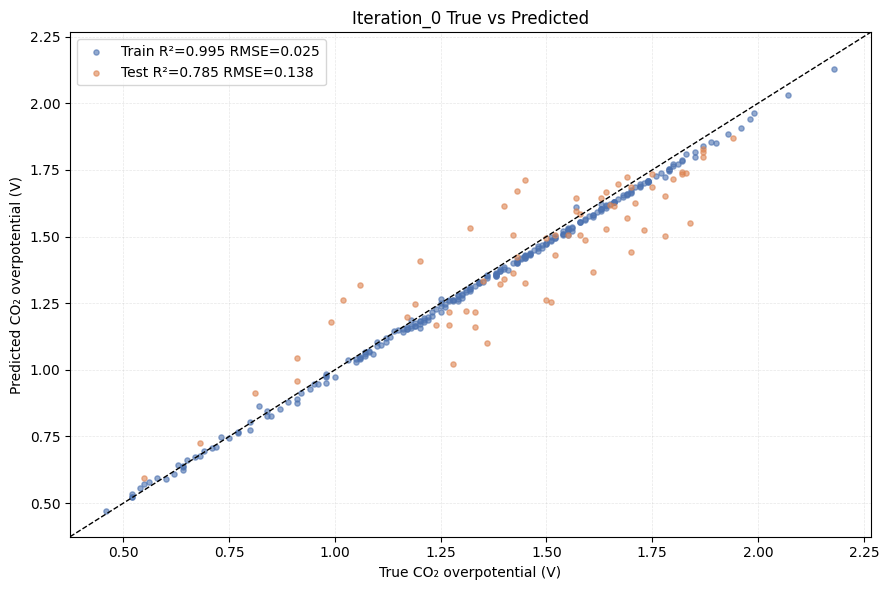

Iteration_0 figure saved to: figure/CO2_iterations/tabpfn_CO2_scatter_0.png
Iteration_0 scatter data saved to: results/CO2_iterations/tabpfn_CO2_scatter_data_0.csv


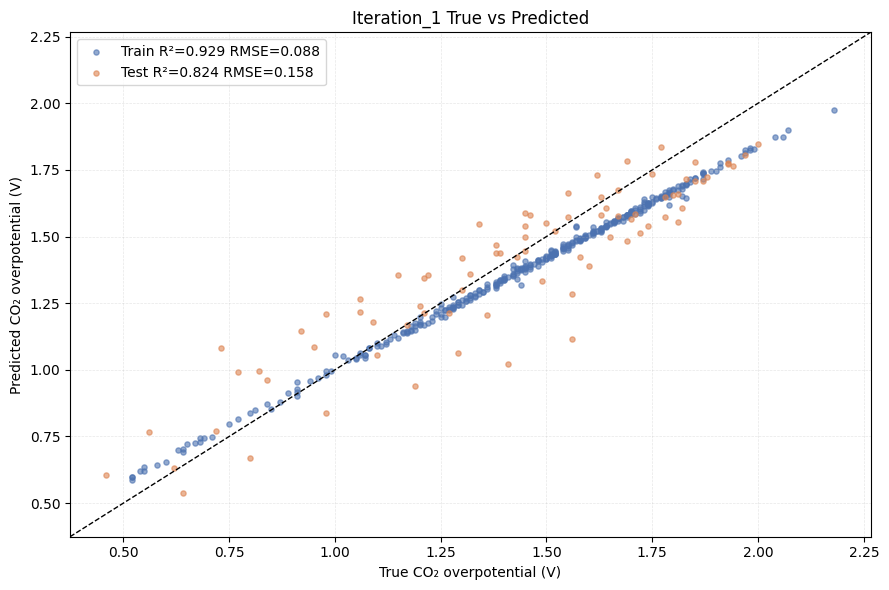

Iteration_1 figure saved to: figure/CO2_iterations/tabpfn_CO2_scatter_1.png
Iteration_1 scatter data saved to: results/CO2_iterations/tabpfn_CO2_scatter_data_1.csv


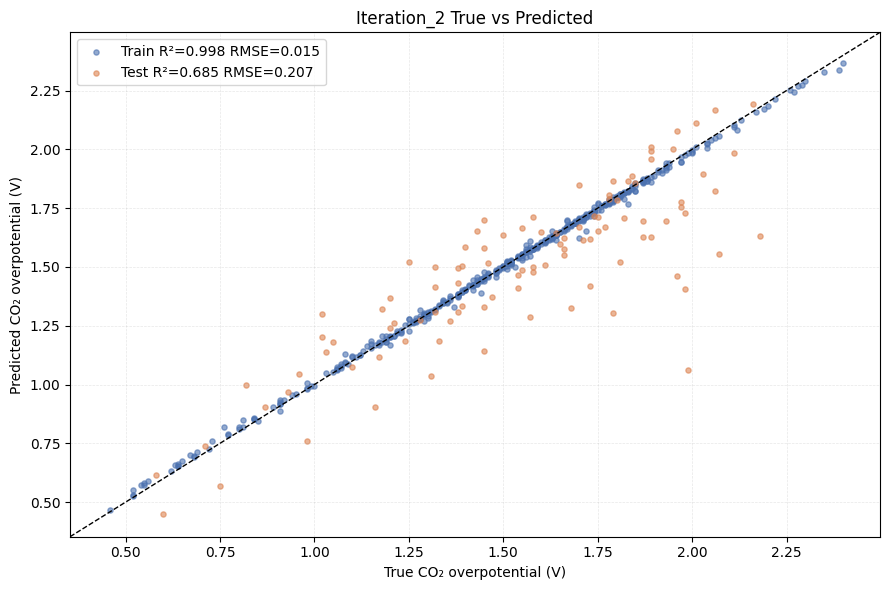

Iteration_2 figure saved to: figure/CO2_iterations/tabpfn_CO2_scatter_2.png
Iteration_2 scatter data saved to: results/CO2_iterations/tabpfn_CO2_scatter_data_2.csv


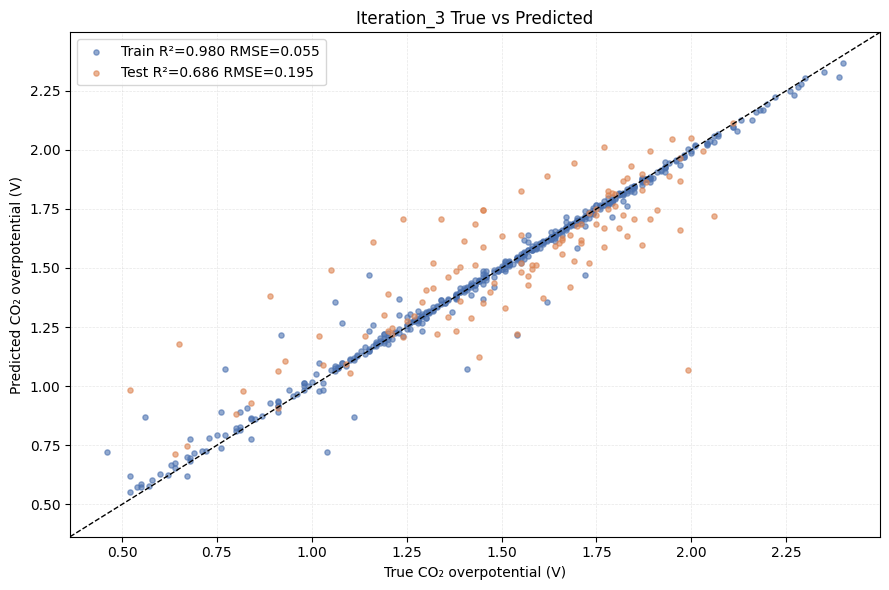

Iteration_3 figure saved to: figure/CO2_iterations/tabpfn_CO2_scatter_3.png
Iteration_3 scatter data saved to: results/CO2_iterations/tabpfn_CO2_scatter_data_3.csv


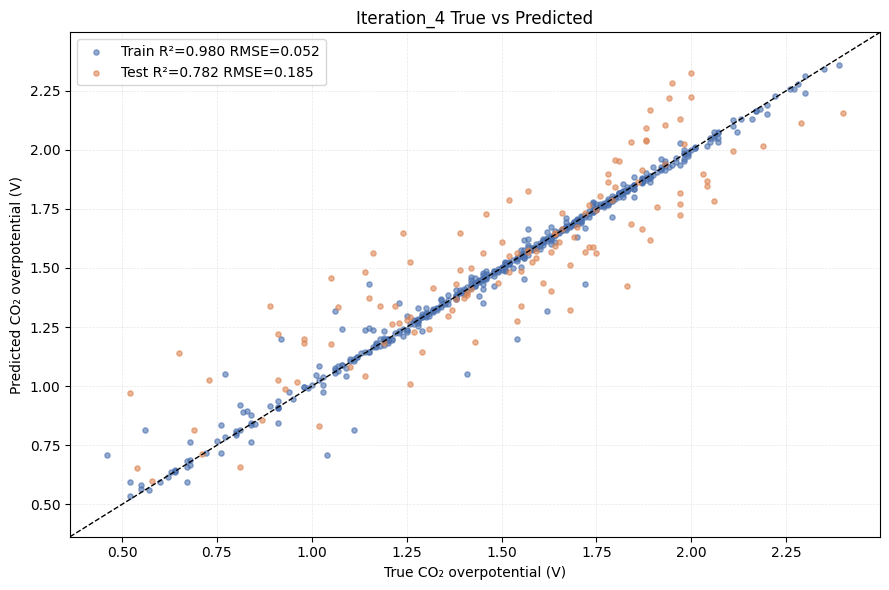

Iteration_4 figure saved to: figure/CO2_iterations/tabpfn_CO2_scatter_4.png
Iteration_4 scatter data saved to: results/CO2_iterations/tabpfn_CO2_scatter_data_4.csv


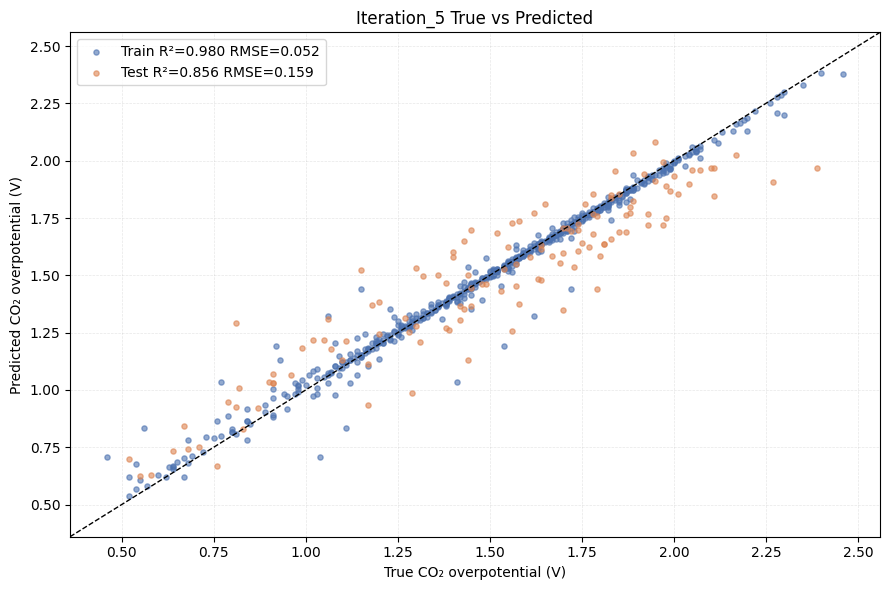

Iteration_5 figure saved to: figure/CO2_iterations/tabpfn_CO2_scatter_5.png
Iteration_5 scatter data saved to: results/CO2_iterations/tabpfn_CO2_scatter_data_5.csv


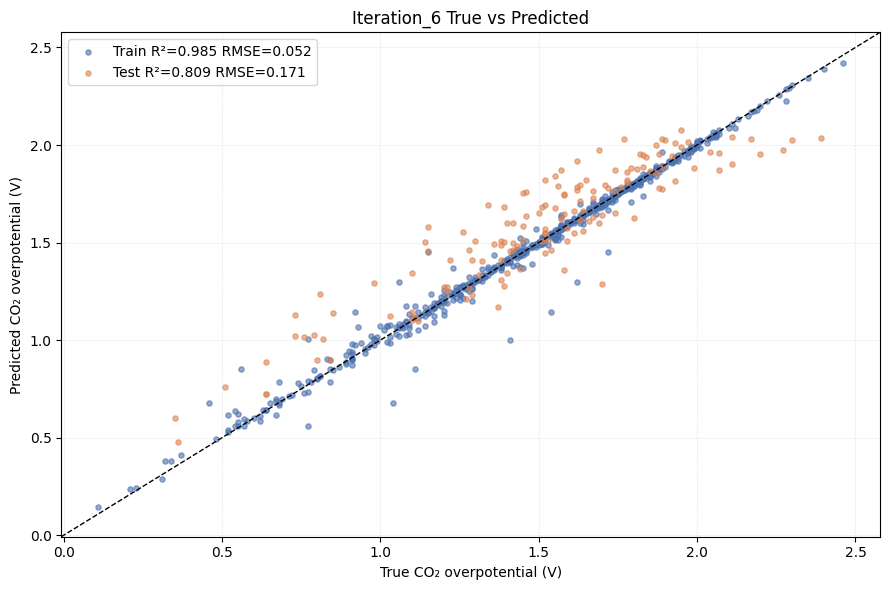

Iteration_6 figure saved to: figure/CO2_iterations/tabpfn_CO2_scatter_6.png
Iteration_6 scatter data saved to: results/CO2_iterations/tabpfn_CO2_scatter_data_6.csv


In [6]:
# ============================================================
# 6. Plot and save scatter figures
# ============================================================

FIGURE_DIR = Path(
    "figure/CO2_iterations"
)

RESULT_DIR = Path(
    "results/CO2_iterations"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


def r2_rmse(y, p):

    r2 = r2_score(
        y,
        p
    )

    rmse = np.sqrt(
        mean_squared_error(
            y,
            p
        )
    )

    return r2, rmse


for iteration_name, iteration in iteration_data.items():

    iteration_number = (
        iteration_name.split("_")[-1]
    )

    y_tr = np.asarray(
        iteration["y_train"]
    ).ravel()

    y_te = np.asarray(
        iteration["y_test"]
    ).ravel()

    p_tr = np.asarray(
        iteration["train_pred"]
    ).ravel()

    p_te = np.asarray(
        iteration["test_pred"]
    ).ravel()


    # Calculate metrics
    r2_tr, rmse_tr = r2_rmse(
        y_tr,
        p_tr
    )

    r2_te, rmse_te = r2_rmse(
        y_te,
        p_te
    )


    # Determine plotting range
    lo = float(
        min(
            y_tr.min(),
            y_te.min(),
            p_tr.min(),
            p_te.min()
        )
    )

    hi = float(
        max(
            y_tr.max(),
            y_te.max(),
            p_tr.max(),
            p_te.max()
        )
    )

    axis_range = hi - lo

    padding = (
        axis_range * 0.05
        if axis_range > 0
        else 0.1
    )

    plot_min = lo - padding
    plot_max = hi + padding


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(9, 6)
    )

    ax.scatter(
        y_tr,
        p_tr,
        s=14,
        alpha=0.6,
        color="#4C72B0",
        label=(
            f"Train R²={r2_tr:.3f} "
            f"RMSE={rmse_tr:.3f}"
        )
    )

    ax.scatter(
        y_te,
        p_te,
        s=14,
        alpha=0.6,
        color="#DD8452",
        label=(
            f"Test R²={r2_te:.3f} "
            f"RMSE={rmse_te:.3f}"
        )
    )

    ax.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        "--",
        color="black",
        lw=1
    )

    ax.set_xlim(
        plot_min,
        plot_max
    )

    ax.set_ylim(
        plot_min,
        plot_max
    )

    ax.set_xlabel(
        "True CO₂ overpotential (V)"
    )

    ax.set_ylabel(
        "Predicted CO₂ overpotential (V)"
    )

    ax.set_title(
        f"{iteration_name} True vs Predicted"
    )

    ax.legend()

    ax.grid(
        alpha=0.3,
        linestyle="--",
        linewidth=0.5
    )

    fig.tight_layout()


    # Save figure
    FIGURE_PATH = (
        FIGURE_DIR
        / f"tabpfn_CO2_scatter_{iteration_number}.png"
    )

    fig.savefig(
        FIGURE_PATH,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


    # --------------------------------------------------------
    # Save scatter data
    # --------------------------------------------------------

    scatter_data = pd.DataFrame({
        "Train_True": pd.Series(y_tr),
        "Train_Predicted": pd.Series(p_tr),
        "Test_True": pd.Series(y_te),
        "Test_Predicted": pd.Series(p_te)
    })

    SCATTER_DATA_PATH = (
        RESULT_DIR
         / f"tabpfn_CO2_scatter_data_{iteration_number}.csv"
     )

    scatter_data.to_csv(
        SCATTER_DATA_PATH,
        index=False
     )


    print(
        f"{iteration_name} figure saved to: "
        f"{FIGURE_PATH}"
    )

    print(
        f"{iteration_name} scatter data saved to: "
        f"{SCATTER_DATA_PATH}"
    )

## feature importance

In [8]:
# ============================================================
# TabPFN permutation importance for Iteration 6
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    r2_score,
    mean_squared_error
)


# ============================================================
# 1. Configuration
# ============================================================

MAX_EVAL_SAMPLES = 256
N_REPEATS = 3
BATCH_SIZE = 4096

OUTPUT_DIR = Path(
    "results/CO2_iterations"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. Get the Iteration 6 model and test data
# ============================================================

final_iteration = (
    iteration_data["Iteration_6"]
)

regressor = (
    final_iteration["regressor"]
)

X_test = np.asarray(
    final_iteration["X_test"],
    dtype=np.float32
)

y_test = np.asarray(
    final_iteration["y_test"],
    dtype=np.float32
).reshape(-1)


# ============================================================
# 3. Feature names and groups
# ============================================================

feat_names = [
    "AB_AN", "AB_AW", "AB_CR", "AB_AR",
    "AB_FIE", "AB_SIE", "AB_EA", "AB_EN",
    "AB_Nd", "AB_Nv", "AB_D", "AB_EC", "AB_TC",
    "C_AN", "C_AW", "C_CR", "C_AR", "C_VR",
    "C_FIE", "C_SIE", "C_EA", "C_EN",
    "C_Np", "C_Nv", "C_D",
    "a_1", "b_1", "c_1", "Grain_1",
    "a_2", "b_2", "c_2", "Grain_2",
    "CurrentDensity"
]


assert X_test.shape[1] == len(
    feat_names
), (
    "The number of feature names does not match "
    "the number of model features."
)


groups = {
    "AB_*": [
        i
        for i, feature in enumerate(feat_names)
        if feature.startswith("AB_")
    ],

    "C_*": [
        i
        for i, feature in enumerate(feat_names)
        if feature.startswith("C_")
    ],

    "Lattice_1": [
        feat_names.index(name)
        for name in [
            "a_1",
            "b_1",
            "c_1",
            "Grain_1"
        ]
    ],

    "Lattice_2": [
        feat_names.index(name)
        for name in [
            "a_2",
            "b_2",
            "c_2",
            "Grain_2"
        ]
    ],

    "CurrentDensity": [
        feat_names.index(
            "CurrentDensity"
        )
    ]
}


# ============================================================
# 4. Common functions
# ============================================================

def rmse(
    y_true,
    y_pred
):

    return np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


def predict_batched(
    model,
    X,
    batch_size=4096
):

    X_array = np.asarray(
        X,
        dtype=np.float32
    )

    predictions = []

    for start in range(
        0,
        len(X_array),
        batch_size
    ):

        end = min(
            start + batch_size,
            len(X_array)
        )

        prediction = model.predict(
            X_array[start:end]
        )

        predictions.append(
            np.asarray(
                prediction
            ).reshape(-1)
        )

    return np.concatenate(
        predictions
    )


def baseline_scores(
    model,
    X,
    y,
    batch_size=4096
):

    prediction = predict_batched(
        model,
        X,
        batch_size=batch_size
    )

    baseline_r2 = r2_score(
        y,
        prediction
    )

    baseline_rmse = rmse(
        y,
        prediction
    )

    return baseline_r2, baseline_rmse


def make_eval_subset(
    X,
    y,
    max_n=256,
    seed=2025
):

    if len(X) <= max_n:

        return X, y

    rng = np.random.RandomState(
        seed
    )

    indices = rng.choice(
        len(X),
        size=max_n,
        replace=False
    )

    return (
        X[indices],
        y[indices]
    )


# ============================================================
# 5. Individual permutation importance
# ============================================================

def permutation_importance_reg(
    model,
    X,
    y,
    feature_names,
    n_repeats=3,
    random_state=42,
    batch_size=4096,
    score_metric="r2",
    normalize="minmax"
):

    rng = np.random.RandomState(
        random_state
    )

    X_validation = np.asarray(
        X,
        dtype=np.float32
    )

    base_r2, base_rmse = baseline_scores(
        model,
        X_validation,
        y,
        batch_size=batch_size
    )

    rows = []


    for feature_index, feature_name in enumerate(
        feature_names
    ):

        rmse_increases = []
        r2_drops = []


        for repeat in range(
            n_repeats
        ):

            X_permuted = (
                X_validation.copy()
            )

            indices = rng.permutation(
                len(X_permuted)
            )

            X_permuted[
                :,
                feature_index
            ] = X_permuted[
                indices,
                feature_index
            ]


            prediction = predict_batched(
                model,
                X_permuted,
                batch_size=batch_size
            )

            permuted_rmse = rmse(
                y,
                prediction
            )

            permuted_r2 = r2_score(
                y,
                prediction
            )


            rmse_increases.append(
                permuted_rmse
                - base_rmse
            )

            r2_drops.append(
                base_r2
                - permuted_r2
            )


        rows.append([
            feature_name,
            np.mean(
                rmse_increases
            ),
            np.std(
                rmse_increases
            ),
            np.mean(
                r2_drops
            ),
            np.std(
                r2_drops
            )
        ])


        print(
            f"Feature "
            f"{feature_index + 1}/"
            f"{len(feature_names)}: "
            f"{feature_name}"
        )


    results = pd.DataFrame(
        rows,
        columns=[
            "feature",
            "rmse_increase_mean",
            "rmse_increase_std",
            "r2_drop_mean",
            "r2_drop_std"
        ]
    )


    if score_metric == "rmse":

        values = results[
            "rmse_increase_mean"
        ].to_numpy()

        standard_deviations = results[
            "rmse_increase_std"
        ].to_numpy()

    else:

        values = results[
            "r2_drop_mean"
        ].to_numpy()

        standard_deviations = results[
            "r2_drop_std"
        ].to_numpy()


    epsilon = 1e-12


    if normalize == "share":

        scores = (
            values
            / (
                values.sum()
                + epsilon
            )
        )

    else:

        scores = (
            (values - values.min())
            / (
                values.max()
                - values.min()
                + epsilon
            )
        )


    results["score"] = scores

    results["snr"] = (
        values
        / (
            standard_deviations
            + epsilon
        )
    )


    results = (
        results
        .sort_values(
            [
                "score",
                "snr"
            ],
            ascending=False
        )
        .reset_index(drop=True)
    )


    results["rank"] = np.arange(
        1,
        len(results) + 1
    )


    return (
        results,
        (
            base_r2,
            base_rmse
        )
    )


# ============================================================
# 6. Grouped permutation importance
# ============================================================

def grouped_permutation_importance_reg(
    model,
    X,
    y,
    groups,
    n_repeats=3,
    random_state=42,
    score_metric="r2",
    normalize="minmax",
    batch_size=4096
):

    rng = np.random.RandomState(
        random_state
    )

    X_validation = np.asarray(
        X,
        dtype=np.float32
    )

    base_r2, base_rmse = baseline_scores(
        model,
        X_validation,
        y,
        batch_size=batch_size
    )

    rows = []


    for group_name, group_columns in (
        groups.items()
    ):

        rmse_increases = []
        r2_drops = []


        for repeat in range(
            n_repeats
        ):

            X_permuted = (
                X_validation.copy()
            )

            indices = rng.permutation(
                len(X_permuted)
            )


            X_permuted[
                :,
                group_columns
            ] = X_permuted[
                indices
            ][
                :,
                group_columns
            ]


            prediction = predict_batched(
                model,
                X_permuted,
                batch_size=batch_size
            )

            permuted_rmse = rmse(
                y,
                prediction
            )

            permuted_r2 = r2_score(
                y,
                prediction
            )


            rmse_increases.append(
                permuted_rmse
                - base_rmse
            )

            r2_drops.append(
                base_r2
                - permuted_r2
            )


        rows.append([
            group_name,
            np.mean(
                rmse_increases
            ),
            np.std(
                rmse_increases
            ),
            np.mean(
                r2_drops
            ),
            np.std(
                r2_drops
            ),
            len(group_columns)
        ])


        print(
            f"Group completed: "
            f"{group_name}"
        )


    results = pd.DataFrame(
        rows,
        columns=[
            "group",
            "rmse_increase_mean",
            "rmse_increase_std",
            "r2_drop_mean",
            "r2_drop_std",
            "size"
        ]
    )


    if score_metric == "rmse":

        values = results[
            "rmse_increase_mean"
        ].to_numpy()

        standard_deviations = results[
            "rmse_increase_std"
        ].to_numpy()

    else:

        values = results[
            "r2_drop_mean"
        ].to_numpy()

        standard_deviations = results[
            "r2_drop_std"
        ].to_numpy()


    epsilon = 1e-12


    if normalize == "share":

        scores = (
            values
            / (
                values.sum()
                + epsilon
            )
        )

    else:

        scores = (
            (values - values.min())
            / (
                values.max()
                - values.min()
                + epsilon
            )
        )


    results["score"] = scores

    results["per_feature"] = (
        values
        / (
            results["size"].to_numpy()
            + epsilon
        )
    )

    results["snr"] = (
        values
        / (
            standard_deviations
            + epsilon
        )
    )


    results = (
        results
        .sort_values(
            [
                "score",
                "snr"
            ],
            ascending=False
        )
        .reset_index(drop=True)
    )


    results["rank"] = np.arange(
        1,
        len(results) + 1
    )


    return (
        results,
        (
            base_r2,
            base_rmse
        )
    )


# ============================================================
# 7. Run feature importance analysis
# ============================================================

X_eval, y_eval = make_eval_subset(
    X_test,
    y_test,
    max_n=MAX_EVAL_SAMPLES,
    seed=2025
)


print("Using model: Iteration_6")
print("Evaluation samples:", len(X_eval))
print("Number of repeats:", N_REPEATS)


print(
    "\nComputing individual "
    "permutation importance..."
)


perm_df, baseline = (
    permutation_importance_reg(
        regressor,
        X_eval,
        y_eval,
        feat_names,
        n_repeats=N_REPEATS,
        random_state=11,
        batch_size=BATCH_SIZE,
        score_metric="r2",
        normalize="minmax"
    )
)


print("\nBaseline performance:")

print(
    f"R2={baseline[0]:.6f}, "
    f"RMSE={baseline[1]:.6f}"
)


print("\nTop 15 features:")

print(
    perm_df
    .head(15)
    .to_string(index=False)
)


FEATURE_OUTPUT = (
    OUTPUT_DIR
    / "iteration_6_perm_feature_importance_CO2.csv"
)

perm_df.to_csv(
    FEATURE_OUTPUT,
    index=False
)

print(
    f"Saved: {FEATURE_OUTPUT}"
)


print(
    "\nComputing grouped "
    "permutation importance..."
)


gperm_df, _ = (
    grouped_permutation_importance_reg(
        regressor,
        X_eval,
        y_eval,
        groups,
        n_repeats=N_REPEATS,
        random_state=12,
        batch_size=BATCH_SIZE,
        score_metric="r2",
        normalize="minmax"
    )
)


print("\nGrouped importance:")

print(
    gperm_df.to_string(
        index=False
    )
)


GROUP_OUTPUT = (
    OUTPUT_DIR
    / "iteration_6_perm_group_importance_CO2.csv"
)

gperm_df.to_csv(
    GROUP_OUTPUT,
    index=False
)

print(
    f"Saved: {GROUP_OUTPUT}"
)

Using model: Iteration_6
Evaluation samples: 145
Number of repeats: 3

Computing individual permutation importance...
Feature 1/34: AB_AN
Feature 2/34: AB_AW
Feature 3/34: AB_CR
Feature 4/34: AB_AR
Feature 5/34: AB_FIE
Feature 6/34: AB_SIE
Feature 7/34: AB_EA
Feature 8/34: AB_EN
Feature 9/34: AB_Nd
Feature 10/34: AB_Nv
Feature 11/34: AB_D
Feature 12/34: AB_EC
Feature 13/34: AB_TC
Feature 14/34: C_AN
Feature 15/34: C_AW
Feature 16/34: C_CR
Feature 17/34: C_AR
Feature 18/34: C_VR
Feature 19/34: C_FIE
Feature 20/34: C_SIE
Feature 21/34: C_EA
Feature 22/34: C_EN
Feature 23/34: C_Np
Feature 24/34: C_Nv
Feature 25/34: C_D
Feature 26/34: a_1
Feature 27/34: b_1
Feature 28/34: c_1
Feature 29/34: Grain_1
Feature 30/34: a_2
Feature 31/34: b_2
Feature 32/34: c_2
Feature 33/34: Grain_2
Feature 34/34: CurrentDensity

Baseline performance:
R2=0.809327, RMSE=0.170739

Top 15 features:
       feature  rmse_increase_mean  rmse_increase_std  r2_drop_mean  r2_drop_std    score       snr  rank
CurrentDensi